### Import library

In [8]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
import os
import shap
import pickle
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


### Load dataset 

In [9]:
df = pd.read_csv('../dataset/data/train.csv')
df.head(20)

,Timestamp,Open,High,Low,Close,Volume
0,1.553935e+09,4071.17,4071.17,4067.74,4067.74,4.587708
1,1.539865e+09,6431.90,6432.91,6429.81,6432.91,5.358719
2,1.379555e+09,127.96,127.96,127.80,127.80,0.457695
3,1.762841e+09,105322.00,105322.00,105266.00,105267.00,0.339559
4,1.446742e+09,385.77,386.92,385.76,386.92,22.224000
5,1.700457e+09,37354.00,37354.00,37354.00,37354.00,15.626177
6,1.340119e+09,6.47,6.47,6.47,6.47,0.000000
7,1.539675e+09,6433.49,6433.49,6428.79,6428.79,3.068286
8,1.720013e+09,60554.00,60558.00,60529.00,60529.00,0.697651
9,1.727068e+09,63877.00,63877.00,63683.00,63683.00,9.207357


### Time Conversion & Resampling:

In [10]:
# ubah timestamp ke datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'].astype(int), unit='s')

# set sebagai index (wajib untuk time series)
df.set_index('Timestamp', inplace=True)

data = df['Close']

data.head()

Timestamp
2019-03-30 08:38:00      4067.74
2018-10-18 12:24:00      6432.91
2013-09-19 01:45:00       127.80
2025-11-11 05:58:00    105267.00
2015-11-05 16:39:00       386.92
Name: Close, dtype: float64

In [11]:
data = data.resample('1h').mean().dropna()

#### Missing Data Imputation:

In [12]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [13]:
print("Data Training")
df.describe()

Data Training


,Open,High,Low,Close,Volume
count,6.012038e+06,6.012038e+06,6.012038e+06,6.012038e+06,6.012038e+06
mean,2.275733e+04,2.276539e+04,2.274909e+04,2.275735e+04,5.050939e+00
std,3.096599e+04,3.097441e+04,3.095750e+04,3.096602e+04,2.189686e+01
min,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,4.517900e+02,4.519700e+02,4.515500e+02,4.517900e+02,2.120705e-02
50%,7.719400e+03,7.723890e+03,7.714195e+03,7.719500e+03,4.573510e-01
75%,3.613171e+04,3.615650e+04,3.610400e+04,3.613189e+04,2.853782e+00
max,1.261980e+05,1.262390e+05,1.261580e+05,1.262020e+05,5.853852e+03


### Stationarity Audit:

In [14]:


hasil = adfuller(data)

print("ADF Statistic:", hasil[0])
print("p-value:", hasil[1])
print("Critical Values:")
for key, value in hasil[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.6386821633850991
p-value: 0.8619997402390778
Critical Values:
1%: -3.430402240246844
5%: -2.8615630894218396
10%: -2.566782289682375


### Temporal Transformation

In [15]:
data_diff = data.diff().dropna()

hasil_diff = adfuller(data_diff)

print("p-value setelah differencing:", hasil_diff[1])

p-value setelah differencing: 0.0


### Autocorrelation Check:

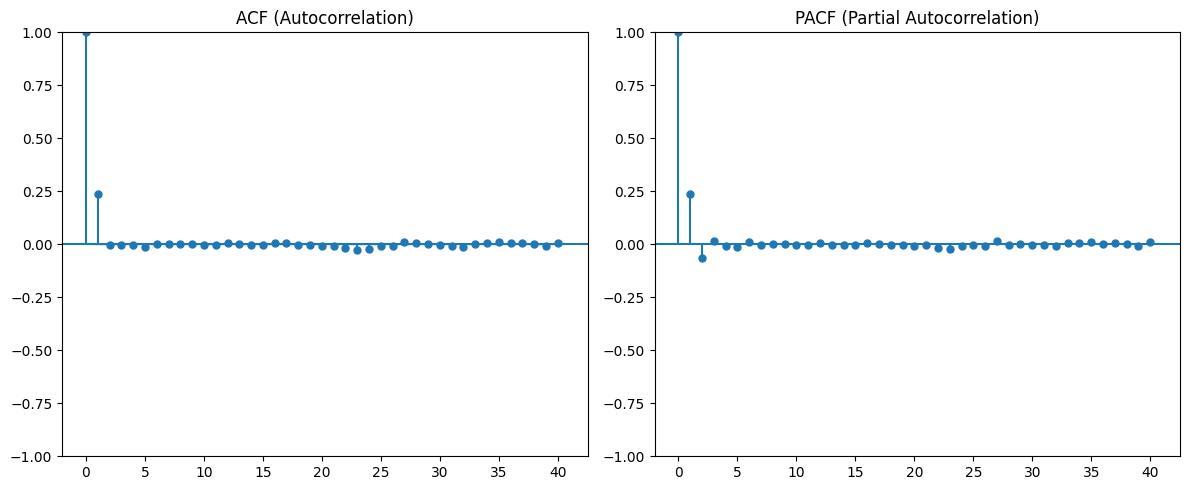

In [16]:


# gunakan data yang SUDAH stasioner (hasil differencing)
plt.figure(figsize=(12,5))

# ACF
plt.subplot(1,2,1)
plot_acf(data_diff, lags=40, ax=plt.gca())
plt.title('ACF (Autocorrelation)')

# PACF
plt.subplot(1,2,2)
plot_pacf(data_diff, lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF (Partial Autocorrelation)')

plt.tight_layout()
plt.show()

### Scalling data 

In [17]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

### Membuat Sequence

In [18]:
def create_dataset(data, time_step=24, future_step=7):  # Input 24 jam, output 7 jam
    X, y = [], []
    # Loop disesuaikan agar indeks data target tidak melampaui panjang dataset
    for i in range(len(data) - time_step - future_step + 1):
        X.append(data[i : i+time_step])
        # Mengambil potongan sequence sepanjang future_step setelah time_step
        y.append(data[i+time_step : i+time_step+future_step])
    return np.array(X), np.array(y)

TIME_STEP = 24
FUTURE_STEP = 7  # Ubah nilai ini untuk menentukan berapa jam ke depan yang ingin diprediksi sekaligus
X, y = create_dataset(scaled_data, TIME_STEP, FUTURE_STEP)

X.shape, y.shape


((125223, 24, 1), (125223, 7, 1))

### Split data

In [19]:

X_train = X
y_train = y

### Build Model LSTM

In [24]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed

def build_model(units=50, dropout=0.2, future_step=7):
    model = Sequential()
    # --- ENCODER ---
    model.add(Input(shape=(TIME_STEP, 1)))
    model.add(LSTM(units, return_sequences=False)) # Meringkas info sequence input
    model.add(Dropout(dropout))
    
    # --- BRIDGE ---
    # Mengulang output encoder sebanyak future_step (misal 7 kali)
    model.add(RepeatVector(future_step)) 
    
    # --- DECODER ---
    model.add(LSTM(units, return_sequences=True)) # Menghasilkan sequence output
    
    # Menerapkan layer Dense(1) ke setiap timestep dari decoder output secara paralel
    model.add(TimeDistributed(Dense(1))) 
    
    model.compile(optimizer='adam', loss='mse')
    return model


In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Tuning

In [27]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

best_val_loss = float("inf")
best_model = None
best_params = None

for units in [32, 50, 64]:
    for dropout in [0.1, 0.2]:

        K.clear_session()
        print(f"\n[INFO] Memulai training dengan: Units={units}, Dropout={dropout}...")

        model = build_model(units, dropout) 

        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=20,
            batch_size=64,
            callbacks=[early_stop],
            verbose=1 
        )

        val_loss = min(history.history['val_loss'])

        print(
            f"--> SELESAI: Units={units}, "
            f"Dropout={dropout}, "
            f"Val Loss Terbaik={val_loss:.6f}"
        )
        print("-" * 50)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model
            best_params = {
                "units": units,
                "dropout": dropout
            }

print("\n===== BEST MODEL =====")
print("Units      :", best_params["units"])
print("Dropout    :", best_params["dropout"])
print("Val Loss   :", best_val_loss)



[INFO] Memulai training dengan: Units=32, Dropout=0.1...
Epoch 1/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 2.7586e-04 - val_loss: 0.0113
Epoch 2/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - loss: 4.9009e-05 - val_loss: 0.0376
Epoch 3/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 4.1353e-05 - val_loss: 0.0349
Epoch 4/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 3.5855e-05 - val_loss: 0.0359
Epoch 5/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 3.1374e-05 - val_loss: 0.0270
Epoch 6/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 3.0487e-05 - val_loss: 0.0302
--> SELESAI: Units=32, Dropout=0.1, Val Loss Terbaik=0.011306
--------------------------------------------------

[INFO] Memulai training dengan: Units=32, Dropout=0.2...
Epoch 1/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 3.1081e-04 - val_loss: 0.0256
Epoch 2/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 6.8407e-05 - val_loss: 0.0338
Epoch 3/20
1566/156

In [28]:
# Simpan model
best_model.save("../model/lstm_forecasting.keras")

# Simpan scaler
with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model dan scaler berhasil disimpan")

Model dan scaler berhasil disimpan


### SHAP

100%|██████████| 10/10 [04:19<00:00, 25.90s/it]


Shape SHAP values : (10, 24, 7)
Shape Sample data : (10, 24)


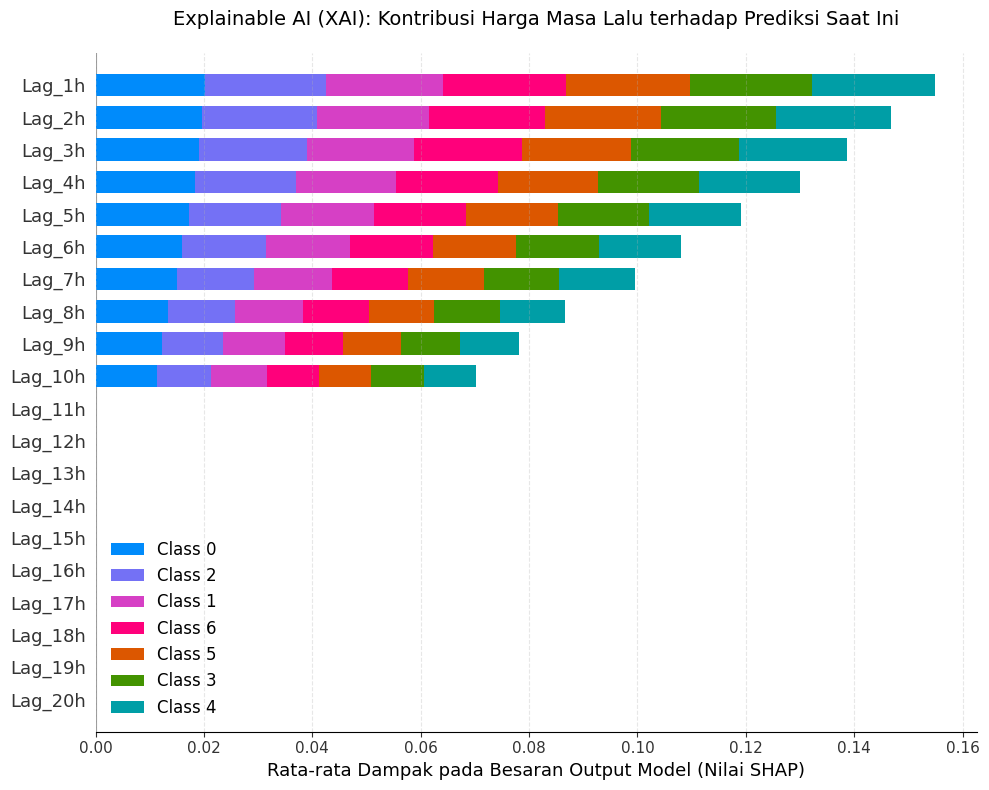

In [31]:
# 1. Define Feature Names (Pengaruh 24 jam ke belakang)
feature_names = [f'Lag_{24-i}h' for i in range(24)]

# 2. Prepare Data
# Flatten X_train menjadi 2D untuk SHAP (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Gunakan shap.sample agar pemilihan background data lebih representatif dan stabil
background_data = shap.sample(X_train_flat, 50) 
sample_data = X_train_flat[:10]

# 3. Wrapper untuk Model LSTM (Disesuaikan untuk Output Multi-Step / Many-to-Many)
def predict_wrapper(x):
    # Kembalikan ke bentuk 3D (samples, timesteps, features) untuk input LSTM
    x_3d = x.reshape(x.shape[0], 24, 1)
    preds = best_model.predict(x_3d, verbose=0)
    
    # Jika output berbentuk 3D (samples, future_step, 1), ubah ke 2D (samples, future_step)
    if len(preds.shape) == 3:
        preds = preds.reshape(preds.shape[0], -1)
        
    return preds

# 4. Hitung SHAP values dengan KernelExplainer
explainer = shap.KernelExplainer(predict_wrapper, background_data)
shap_values = explainer.shap_values(sample_data)

# 5. Penanganan Dimensi yang Aman
# KernelExplainer kadang mengembalikan List (jika multi-output), kita ambil elemen pertamanya
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Pastikan shap_values adalah numpy array 2D
shap_values = np.array(shap_values)

print("Shape SHAP values :", shap_values.shape)
print("Shape Sample data :", sample_data.shape)

# 6. Visualisasi Plot
plt.clf() # Membersihkan kanvas sebelumnya (mencegah plot kosong)

# Generate plot tanpa menampilkan langsung (show=False)
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

# Kustomisasi Figure Matplotlib SETELAH plot SHAP dibuat
fig = plt.gcf()
fig.set_size_inches(10, 8) # Atur ukuran di sini
plt.title("Explainable AI (XAI): Kontribusi Harga Masa Lalu terhadap Prediksi Saat Ini", fontsize=14, pad=20)
plt.xlabel("Rata-rata Dampak pada Besaran Output Model (Nilai SHAP)")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Tampilkan plot
plt.show()


In [32]:


model = load_model("../model/lstm_forecasting.keras")

with open("../model/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Model dan scaler berhasil dimuat")

Model dan scaler berhasil dimuat


In [33]:
# %%
test_df = pd.read_csv("../dataset/data/test.csv")

print(test_df.head())
print(test_df.shape)

      Timestamp      Open      High       Low     Close    Volume
0  1.710000e+09  68337.00  68347.00  68333.00  68333.00  1.873429
1  1.652527e+09  29473.94  29485.67  29468.42  29468.42  1.347478
2  1.646242e+09  44046.03  44047.45  43986.67  43986.67  0.275159
3  1.669388e+09  16435.00  16435.00  16432.00  16433.00  0.442565
4  1.713196e+09  66193.00  66193.00  66192.00  66192.00  0.564461
(1503010, 6)


In [34]:
print("Data Test")
test_df.describe()

Data Test


,Timestamp,Open,High,Low,Close,Volume
count,1.503010e+06,1.503010e+06,1.503010e+06,1.503010e+06,1.503010e+06,1.503010e+06
mean,1.550847e+09,2.276625e+04,2.277431e+04,2.275801e+04,2.276624e+04,5.045259e+00
std,1.302078e+08,3.098675e+04,3.099520e+04,3.097825e+04,3.098674e+04,2.138911e+01
min,1.325412e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,1.438020e+09,4.517000e+02,4.519125e+02,4.515100e+02,4.517500e+02,2.119356e-02
50%,1.550843e+09,7.710350e+03,7.715365e+03,7.706000e+03,7.711045e+03,4.563918e-01
75%,1.663679e+09,3.618499e+04,3.620890e+04,3.615753e+04,3.618357e+04,2.851814e+00
max,1.776384e+09,1.262020e+05,1.262720e+05,1.261570e+05,1.261720e+05,2.958478e+03


In [35]:
# %%
# Ubah timestamp menjadi datetime
test_df['Timestamp'] = pd.to_datetime(
    test_df['Timestamp'].astype(int),
    unit='s'
)

# Jadikan index
test_df.set_index('Timestamp', inplace=True)

# Ambil kolom Close
data_test = test_df['Close']

# Resampling 1 jam
data_test = data_test.resample('1h').mean().dropna()

print(data_test.head())
print("Jumlah data:", len(data_test))

Timestamp
2012-01-01 10:00:00    4.58
2012-01-01 11:00:00    4.58
2012-01-01 12:00:00    4.58
2012-01-01 13:00:00    4.58
2012-01-01 14:00:00    4.58
Name: Close, dtype: float64
Jumlah data: 125252


In [36]:
# %%
scaled_test = scaler.transform(
    data_test.values.reshape(-1,1)
)

print(scaled_test.shape)

(125252, 1)


In [44]:
def create_dataset_test(data, time_step=24, future_step=7):
    X = []
    y = []
    # Loop disesuaikan dengan future_step
    for i in range(len(data) - time_step - future_step + 1):
        X.append(data[i:i+time_step])
        # Mengambil target 7 langkah ke depan
        y.append(data[i+time_step : i+time_step+future_step])

    return np.array(X), np.array(y)

TIME_STEP = 24
FUTURE_STEP = 7 # Samakan dengan model training Anda

X_test, y_test = create_dataset_test(
    scaled_test,
    TIME_STEP,
    FUTURE_STEP
)

print("X_test shape :", X_test.shape) # Output yang benar: (samples, 24, 1)
print("y_test shape :", y_test.shape) # Output yang benar: (samples, 7, 1)


X_test shape : (125222, 24, 1)
y_test shape : (125222, 7, 1)


In [45]:
# %%
y_pred_scaled = model.predict(X_test)

print(y_pred_scaled.shape)

3914/3914 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step
(125222, 7, 1)


In [46]:
# 1. Reshape y_pred_scaled dari 3D ke 2D untuk inverse scaling, lalu kembalikan ke 2D (samples, future_step)
y_pred_flat = y_pred_scaled.reshape(-1, 1)
y_pred = scaler.inverse_transform(y_pred_flat).reshape(y_pred_scaled.shape[0], -1)

# 2. Lakukan hal yang sama untuk y_test (aktual)
y_test_flat = y_test.reshape(-1, 1)
y_actual = scaler.inverse_transform(y_test_flat).reshape(y_test.shape[0], -1)

print("Shape Actual:", y_actual.shape) # Akan menghasilkan (samples, future_step)
print("Shape Pred  :", y_pred.shape)   # Akan menghasilkan (samples, future_step)


Shape Actual: (125222, 7)
Shape Pred  : (125222, 7)


In [47]:
print("\nPrediksi Pertama")

for i in range(10):
    print(
        f"Actual={y_actual[i][0]:.2f} | "
        f"Pred={y_pred[i][0]:.2f}"
    )


Prediksi Pertama
Actual=5.00 | Pred=327.42
Actual=5.00 | Pred=327.43
Actual=5.00 | Pred=327.45
Actual=5.00 | Pred=327.46
Actual=5.00 | Pred=327.47
Actual=5.00 | Pred=327.48
Actual=5.00 | Pred=327.48
Actual=5.00 | Pred=327.49
Actual=5.00 | Pred=327.49
Actual=5.00 | Pred=327.49


In [48]:
# %%


mae = mean_absolute_error(
    y_actual,
    y_pred
)

mse = mean_squared_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(
    y_actual,
    y_pred
)

r2 = r2_score(
    y_actual,
    y_pred
)

print("R2 Score:", r2)

print("="*40)
print("HASIL PENGUJIAN DATA TEST")
print("="*40)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape)

R2 Score: 0.9927736708891342
HASIL PENGUJIAN DATA TEST
MAE  : 1288.8760303212744
MSE  : 6931596.703361685
RMSE : 2632.792567476915
MAPE : 2.6452374499984814


In [49]:
# %%
n = len(y_actual)

k = model.count_params()

aic = n * np.log(mse) + 2 * k

bic = n * np.log(mse) + k * np.log(n)

print("AIC :", aic)
print("BIC :", bic)

AIC : 2072416.9490103787
BIC : 2559163.053411824


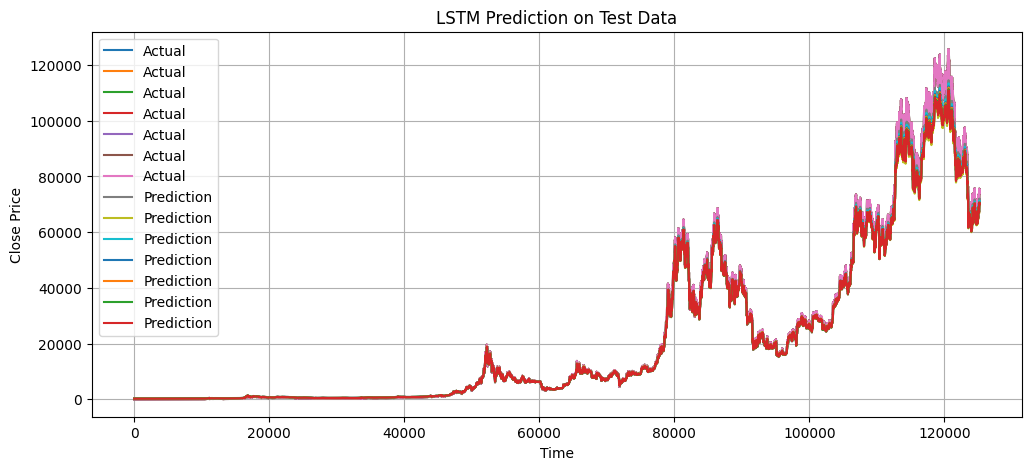

In [50]:
# %%
plt.figure(figsize=(12,5))

plt.plot(
    y_actual,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Prediction"
)

plt.title("LSTM Prediction on Test Data")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()

In [51]:
import pickle
from tensorflow.keras.models import load_model

# Memuat model dan scaler yang telah disimpan sebelumnya
model_forecast = load_model('../model/lstm_forecasting.keras')
with open('../model/scaler.pkl', 'rb') as f:
    scaler_forecast = pickle.load(f)

print("Model dan scaler berhasil dimuat untuk proses forecasting.")


Model dan scaler berhasil dimuat untuk proses forecasting.


In [53]:
import numpy as np

# Transformasikan data Close price aktual menggunakan scaler yang baru di-load
scaled_data_forecast = scaler_forecast.transform(data.values.reshape(-1, 1))

# Ambil 24 data terakhir sebagai sequence awal (TIME_STEP = 24)
TIME_STEP = 24
last_sequence = scaled_data_forecast[-TIME_STEP:]

# Prediksi untuk 7 hari ke depan (7 * 24 jam = 168 jam)
forecast_steps = 7 * 24
FUTURE_STEP = 7  # Jumlah output per prediksi model
forecast_list = []

# Reshape sequence awal menjadi format (1, 24, 1) agar sesuai input LSTM
current_sequence = last_sequence.reshape(1, TIME_STEP, 1)

# Jumlah perulangan yang dibutuhkan (168 jam / 7 jam = 24 kali perulangan)
iterations = forecast_steps // FUTURE_STEP

print(f"Memulai prediksi {forecast_steps} jam ke depan (dalam {iterations} langkah)...")
for i in range(iterations):
    # Prediksi 7 langkah (jam) sekaligus ke depan
    next_pred = model_forecast.predict(current_sequence, verbose=0)
    
    # Pastikan shape next_pred rata menjadi 1D array berukuran 7
    next_pred_flat = next_pred.flatten()
    
    # Simpan ke-7 hasil prediksi tersebut
    forecast_list.extend(next_pred_flat)
    
    # Geser sequence: buang 7 data terlama di awal, masukkan 7 hasil prediksi terbaru di akhir
    next_pred_reshaped = next_pred_flat.reshape(1, FUTURE_STEP, 1)
    current_sequence = np.append(current_sequence[:, FUTURE_STEP:, :], next_pred_reshaped, axis=1)

print("Proses prediksi selesai.")


Memulai prediksi 168 jam ke depan (dalam 24 langkah)...
Proses prediksi selesai.


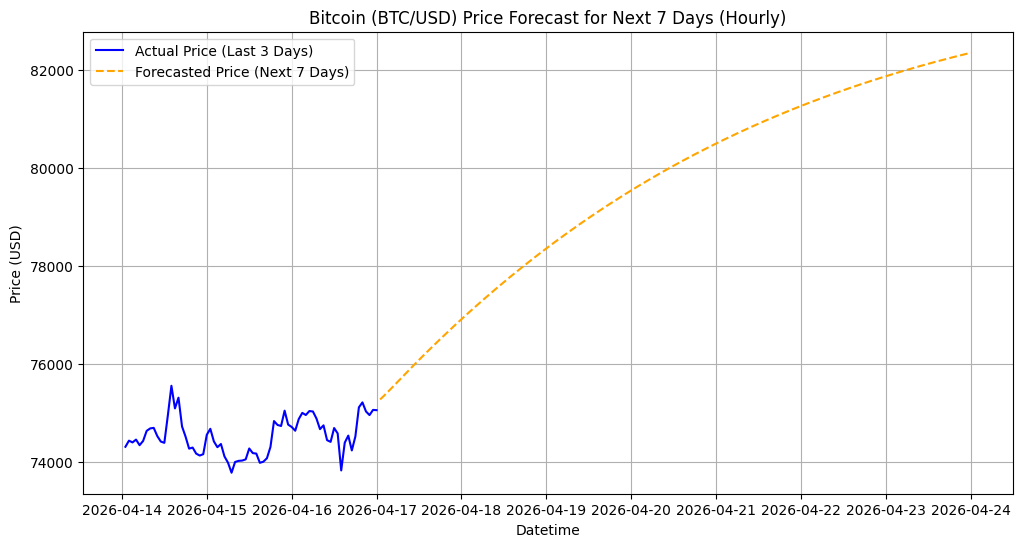

Preview Hasil Forecast:
                     Forecasted_Close
2026-04-17 01:00:00      75279.218750
2026-04-17 02:00:00      75347.710938
2026-04-17 03:00:00      75419.656250
2026-04-17 04:00:00      75493.625000
2026-04-17 05:00:00      75568.523438
2026-04-17 06:00:00      75643.867188
2026-04-17 07:00:00      75719.187500
2026-04-17 08:00:00      75794.062500
2026-04-17 09:00:00      75868.375000
2026-04-17 10:00:00      75942.281250


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Kembalikan skala hasil prediksi ke harga USD asli
forecast_list = np.array(forecast_list).reshape(-1, 1)
forecast_prices = scaler_forecast.inverse_transform(forecast_list)

# Buat index datetime untuk 168 jam ke depan mulai dari timestamp terakhir data aktual
last_timestamp = data.index[-1]
forecast_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1), 
    periods=forecast_steps, 
    freq='h'
)

# Gabungkan hasil ke dalam DataFrame
df_forecast = pd.DataFrame(data=forecast_prices, index=forecast_timestamps, columns=['Forecasted_Close'])

# Visualisasi Hasil Forecast 7 Hari ke Depan
plt.figure(figsize=(12, 6))
# Plot data aktual 3 hari terakhir agar grafik terlihat tersambung secara historis
plt.plot(data.tail(24 * 3), label='Actual Price (Last 3 Days)', color='blue')
# Plot hasil prediksi 7 hari ke depan
plt.plot(df_forecast['Forecasted_Close'], label='Forecasted Price (Next 7 Days)', color='orange', linestyle='--')
plt.title("Bitcoin (BTC/USD) Price Forecast for Next 7 Days (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan preview 10 hasil prediksi pertama
print("Preview Hasil Forecast:")
print(df_forecast.head(10))
